# Variability-Mode Synthetic Metrics: v3.xLE ECS Perturbations

Compare the 25-member lowECS and highECS ensembles separately against the 25-member baseline historical ensemble.


In [7]:
from pathlib import Path
import importlib
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# Reload leaf dependencies before their consumers so notebook reruns use local edits.
import utils
import metrics_group_merger
import movs_metrics_reader
import synthetic_metrics_plotter
import synthetic_metrics_workflow
importlib.reload(utils)
importlib.reload(metrics_group_merger)
importlib.reload(movs_metrics_reader)
importlib.reload(synthetic_metrics_plotter)
importlib.reload(synthetic_metrics_workflow)

from metrics_group_merger import MetricsGroup, merge_metrics_group
from synthetic_metrics_workflow import (
    dataset_for_merged_group,
    make_comparison_parameters,
    run_synthetic_plots,
)


In [8]:
# Merge three 25-member ensembles, then run two model-versus-model comparisons.
MOV_MVM_XLE_RUN_MERGE = False  # Set False after merged files have been created.
MOV_MVM_XLE_CLEAN_MERGED_OUTPUT = False
MOV_MVM_XLE_DRY_RUN_MERGE = False
MOV_MVM_XLE_RUN_PLOTS = True
MOV_MVM_XLE_SHOW_FIGURES = True
MOV_MVM_XLE_DEBUG = True
MOV_MVM_XLE_CASE_ID = "v20260822"
MOV_MVM_XLE_FIGURE_FORMAT = "pdf"
MOV_MVM_XLE_FONT_SIZE = 32
MOV_MVM_XLE_FIGURE_SIZE = (60.0, 20.0)
MOV_MVM_XLE_PORTRAIT_FIGURE_SIZE = (50.0, 20.0)
MOV_MVM_XLE_PARCOORD_FIGURE_SIZE = (70.0, 30.0)
MOV_MVM_XLE_PARCOORD_LEGEND_Y_OFFSET = -0.28

MOV_MVM_XLE_SOURCE_ROOT = Path("/global/cfs/cdirs/e3sm/www/zhan391/e3sm_v3xle")
MOV_MVM_XLE_METRICS_DATA_ROOT = MOV_MVM_XLE_SOURCE_ROOT / "metrics_data"
MOV_MVM_XLE_METRIC_CONFIG_FILE = PROJECT_ROOT / "config" / "synthetic_metrics_list.json"
MOV_MVM_XLE_FIG_ROOT = MOV_MVM_XLE_SOURCE_ROOT / "analysis_output"

MOV_MVM_XLE_MIP = "e3sm"
MOV_MVM_XLE_REF_MERGED_GROUP = "xle_historical"
MOV_MVM_XLE_REF_GROUP_LABEL = "v3.LR.historical"

# Explicit metrics and expected figure types.
MOV_MVM_XLE_METRICS = (
    "rms",                   # RMSE; portrait and parallel-coordinate figures
    "rmsc",                  # Centered RMSE; portrait and parallel-coordinate figures
    "stdv_pc_ratio_to_obs",  # PC standard-deviation ratio; both figure types
)

# Explicit figure-set selection: exactly this diagnostic family is enabled.
MOV_MVM_XLE_CLIM_VIEWER = False
MOV_MVM_XLE_MOVA_VIEWER = True
MOV_MVM_XLE_MOVC_VIEWER = True
MOV_MVM_XLE_ENSO_VIEWER = False

MOV_MVM_XLE_SHOW_MEAN_COLUMNS = True
MOV_MVM_XLE_MOVS_GROUP = "cbf"
MOV_MVM_XLE_ATM_MODES = ("NAM", "NAO", "PNA", "NPO")
MOV_MVM_XLE_ATM_OBS = "NOAA-20C"
MOV_MVM_XLE_CPL_MODES = ("PDO", "NPGO")
MOV_MVM_XLE_CPL_OBS = "HadISST2"
MOV_MVM_XLE_ERROR_NORM = "reference"

# Raw group definitions. The patterns discover all 25 member directories.
MOV_MVM_XLE_GROUPS = {
    "historical": MetricsGroup(
        name=MOV_MVM_XLE_REF_MERGED_GROUP, model_pattern="v3.LR.historical_*",
        source_root=MOV_MVM_XLE_SOURCE_ROOT, mips=[MOV_MVM_XLE_MIP],
        exps=["historical"], case_id=MOV_MVM_XLE_CASE_ID,
        movs_years=(1985, 2014),
        movs_obses="NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,HadISST2,HadISST2,HadISST2",
    ),
    "lowECS": MetricsGroup(
        name="xle_lowecs", model_pattern="v3.LR.lowECS.historical_*",
        source_root=MOV_MVM_XLE_SOURCE_ROOT, mips=[MOV_MVM_XLE_MIP],
        exps=["historical"], case_id=MOV_MVM_XLE_CASE_ID,
        movs_years=(1985, 2014),
        movs_obses="NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,HadISST2,HadISST2,HadISST2",
    ),
    "highECS": MetricsGroup(
        name="xle_highecs", model_pattern="v3.LR.highECS.historical_*",
        source_root=MOV_MVM_XLE_SOURCE_ROOT, mips=[MOV_MVM_XLE_MIP],
        exps=["historical"], case_id=MOV_MVM_XLE_CASE_ID,
        movs_years=(1985, 2014),
        movs_obses="NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,NOAA-20C,HadISST2,HadISST2,HadISST2",
    ),
}

MOV_MVM_XLE_COMPARISONS = (
    {"key": "lowECS_vs_historical", "group": "lowECS", "label": "v3.LR.lowECS.historical"},
    {"key": "highECS_vs_historical", "group": "highECS", "label": "v3.LR.highECS.historical"},
)


2026-08-28 17:16:43,719 [INFO]: synthetic_metrics_workflow.py(run_synthetic_plots:645) >> Generating synthetic metrics plots for case_id=v20260822
2026-08-28 17:16:43,719 [INFO]: synthetic_metrics_workflow.py(run_synthetic_plots:650) >> Generating figure_set=variability metrics=[] for case_id=v20260822
2026-08-28 17:16:43,720 [INFO]: synthetic_metrics_plotter.py(generate:366) >> Generating synthetic metrics plots ...
2026-08-28 17:16:43,720 [INFO]: synthetic_metrics_plotter.py(generate:392) >> Processing metric: variability_modes
2026-08-28 17:16:43,721 [INFO]: synthetic_metrics_plotter.py(_handle_variability_modes:493) >> Handling modes variability …
2026-08-28 17:16:43,721 [INFO]: movs_metrics_reader.py(_get_ref_files:159) >> From /pscratch/sd/z/zhan391/e3smv4_project/v4_evaluation/pcmdi_package/jupyter, checking for reference files matching /global/cfs/cdirs/e3sm/www/zhan391/e3sm_v3xle/metrics_data/variability_modes/e3sm/xle_historical/v20260822/*/*/var_mode_*.json
2026-08-28 17:16:

[INFO] Using PROJ data: /global/u2/z/zhan391/.conda/envs/e3sm_analysis/share/proj
Test group: v3.LR.lowECS.historical
Reference group: v3.LR.historical
Models (0): []
Results: /global/cfs/cdirs/e3sm/www/zhan391/e3sm_v3xle/analysis_output/lowECS_vs_historical/model_vs_obs
variability: []


2026-08-28 17:16:44,197 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:928) >> Processing Portrait  Plots for variability_modes rms....
2026-08-28 17:16:44,207 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1154) >> [Portrait]: No e3sm models to plot (e3sm_list empty).
2026-08-28 17:16:44,208 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1197) >> [Portrait] Highlighted model order: ['v3.LR.historical (mean)', 'v3.LR.lowECS.historical (mean)']


len(mode_season_list) = 18
data_nor shape = (18, 52)
data_nor.T shape = (52, 18)
existing data_dict shape = (52, 18)
existing columns (n) = 18


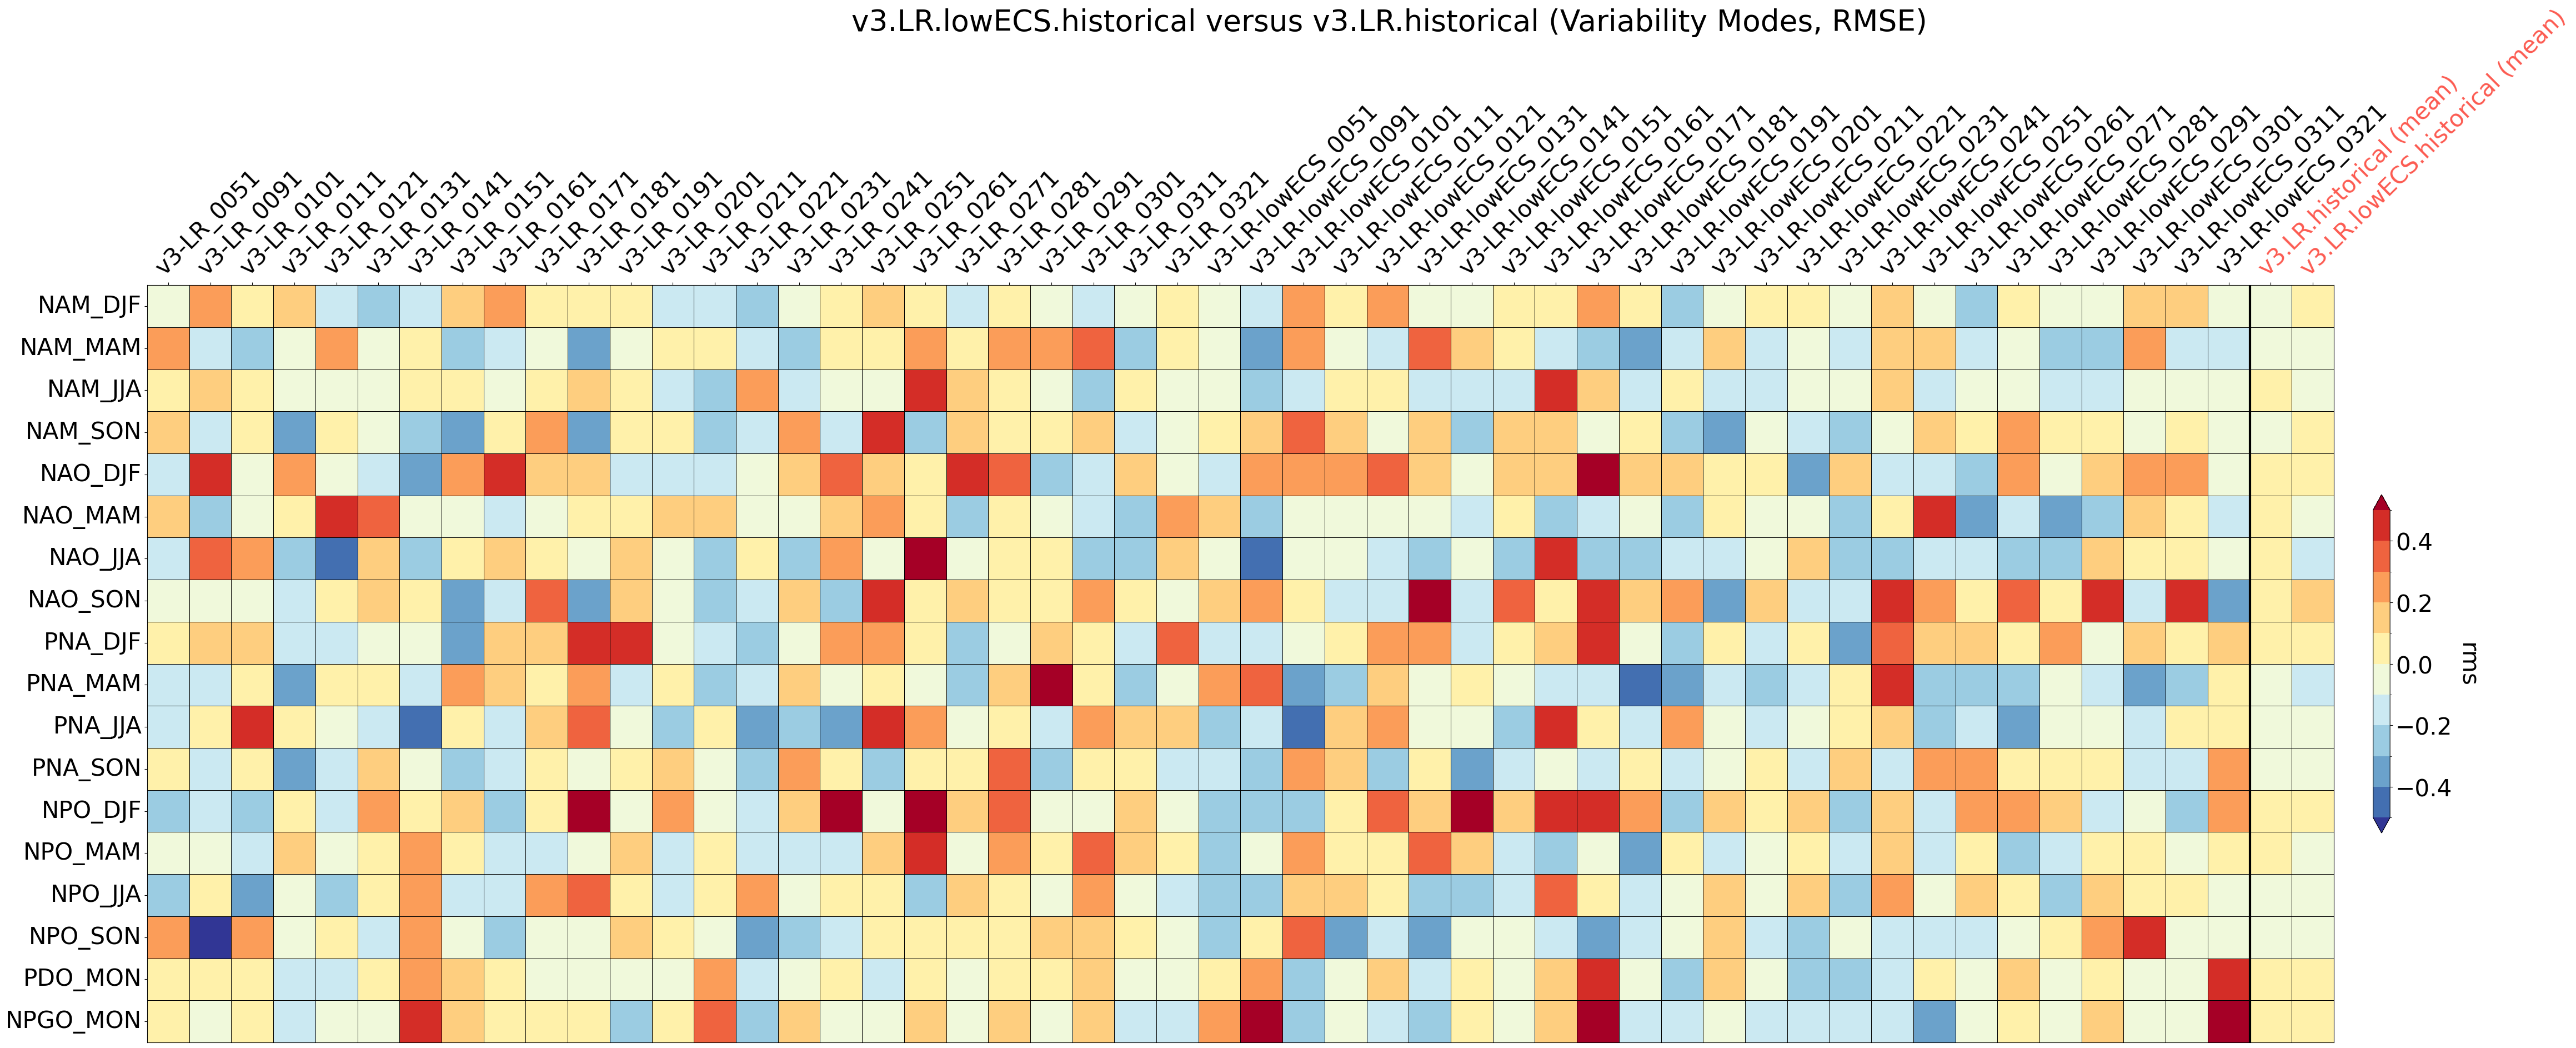

2026-08-28 17:16:46,724 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:979) >> Processing Parallel Coordinate Plots for variability_modes rms....


Models in the second group: ['v3-LR-lowECS_0051', 'v3-LR-lowECS_0091', 'v3-LR-lowECS_0101', 'v3-LR-lowECS_0111', 'v3-LR-lowECS_0121', 'v3-LR-lowECS_0131', 'v3-LR-lowECS_0141', 'v3-LR-lowECS_0151', 'v3-LR-lowECS_0161', 'v3-LR-lowECS_0171', 'v3-LR-lowECS_0181', 'v3-LR-lowECS_0191', 'v3-LR-lowECS_0201', 'v3-LR-lowECS_0211', 'v3-LR-lowECS_0221', 'v3-LR-lowECS_0231', 'v3-LR-lowECS_0241', 'v3-LR-lowECS_0251', 'v3-LR-lowECS_0261', 'v3-LR-lowECS_0271', 'v3-LR-lowECS_0281', 'v3-LR-lowECS_0291', 'v3-LR-lowECS_0301', 'v3-LR-lowECS_0311', 'v3-LR-lowECS_0321', 'v3.LR.lowECS.historical (mean)']


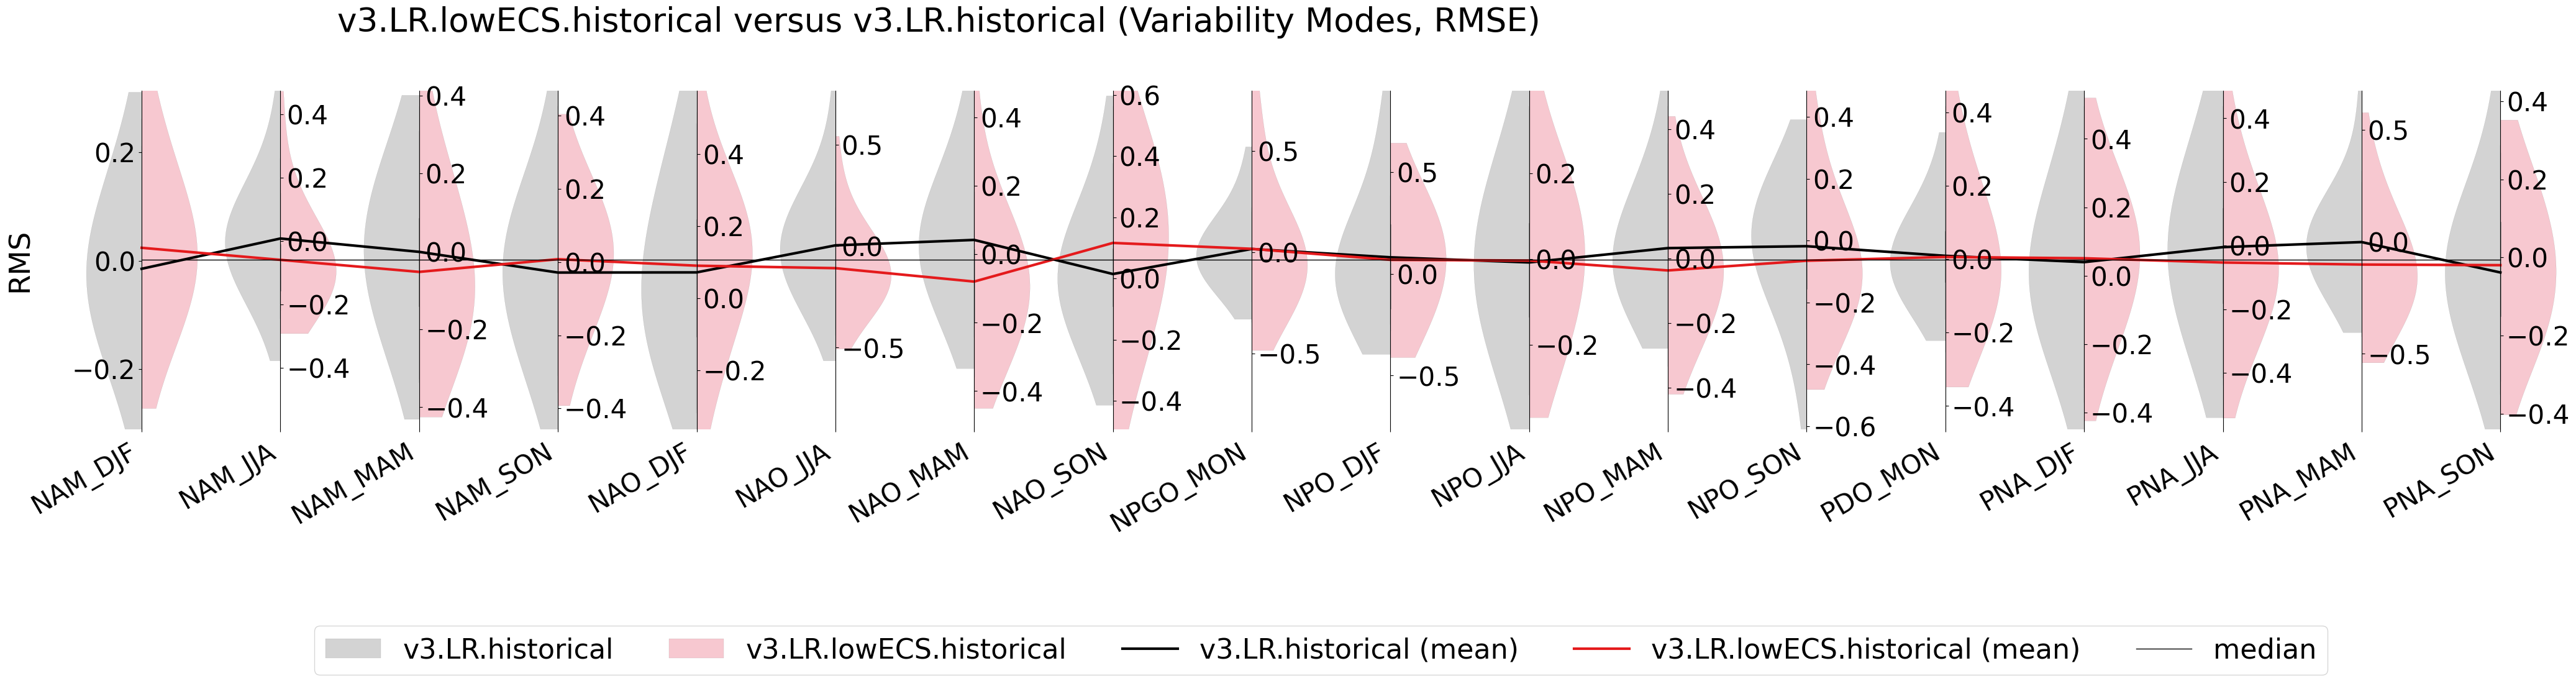

2026-08-28 17:16:49,344 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:928) >> Processing Portrait  Plots for variability_modes rmsc....
2026-08-28 17:16:49,353 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1154) >> [Portrait]: No e3sm models to plot (e3sm_list empty).
2026-08-28 17:16:49,354 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1197) >> [Portrait] Highlighted model order: ['v3.LR.historical (mean)', 'v3.LR.lowECS.historical (mean)']


len(mode_season_list) = 18
data_nor shape = (18, 52)
data_nor.T shape = (52, 18)
existing data_dict shape = (52, 18)
existing columns (n) = 18


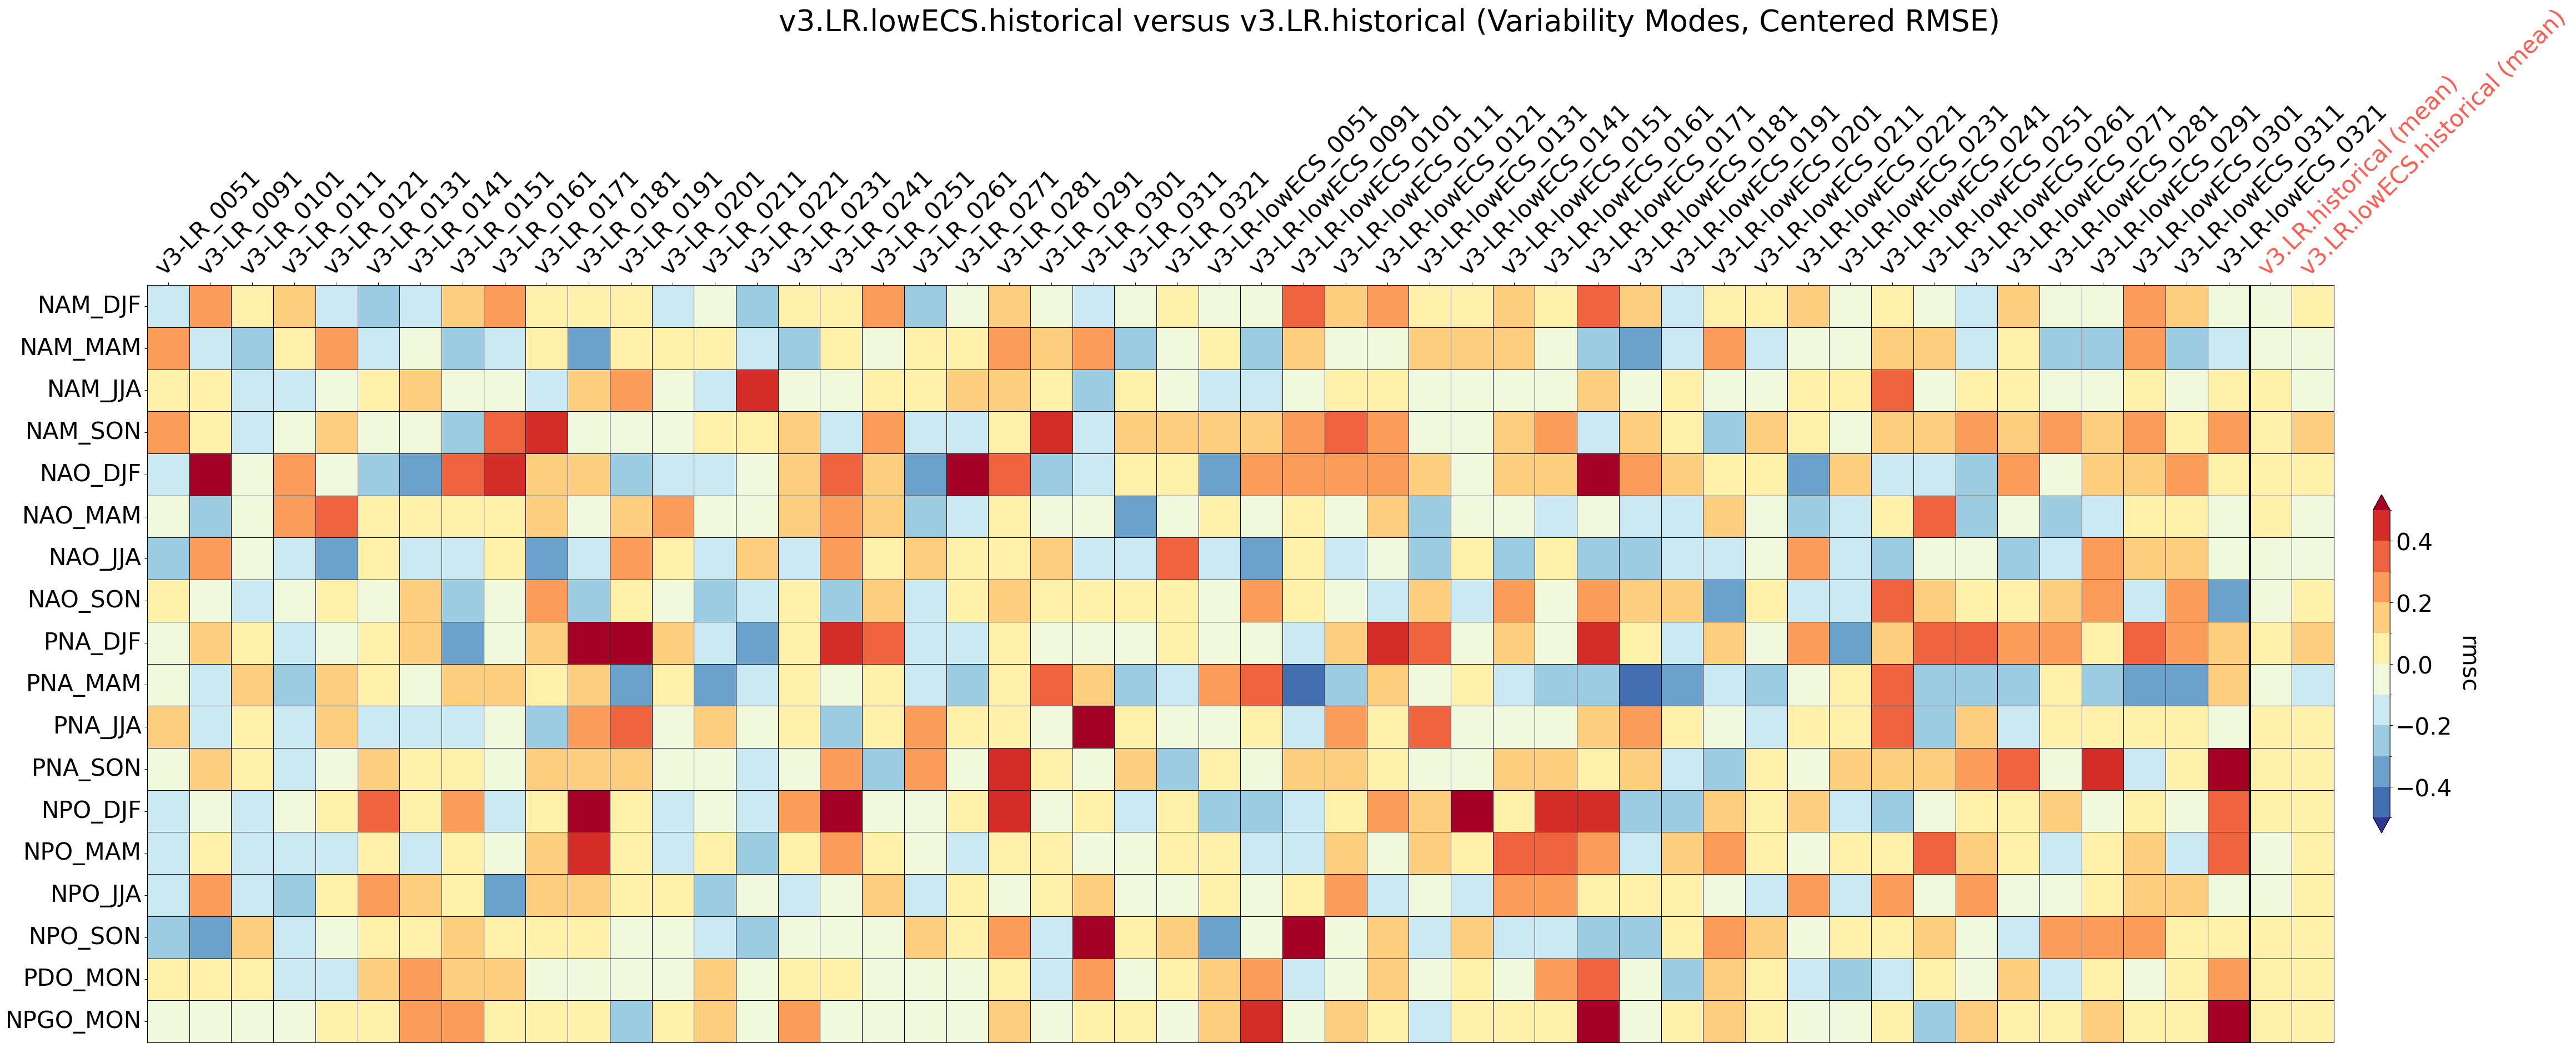

2026-08-28 17:16:51,162 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:979) >> Processing Parallel Coordinate Plots for variability_modes rmsc....


Models in the second group: ['v3-LR-lowECS_0051', 'v3-LR-lowECS_0091', 'v3-LR-lowECS_0101', 'v3-LR-lowECS_0111', 'v3-LR-lowECS_0121', 'v3-LR-lowECS_0131', 'v3-LR-lowECS_0141', 'v3-LR-lowECS_0151', 'v3-LR-lowECS_0161', 'v3-LR-lowECS_0171', 'v3-LR-lowECS_0181', 'v3-LR-lowECS_0191', 'v3-LR-lowECS_0201', 'v3-LR-lowECS_0211', 'v3-LR-lowECS_0221', 'v3-LR-lowECS_0231', 'v3-LR-lowECS_0241', 'v3-LR-lowECS_0251', 'v3-LR-lowECS_0261', 'v3-LR-lowECS_0271', 'v3-LR-lowECS_0281', 'v3-LR-lowECS_0291', 'v3-LR-lowECS_0301', 'v3-LR-lowECS_0311', 'v3-LR-lowECS_0321', 'v3.LR.lowECS.historical (mean)']


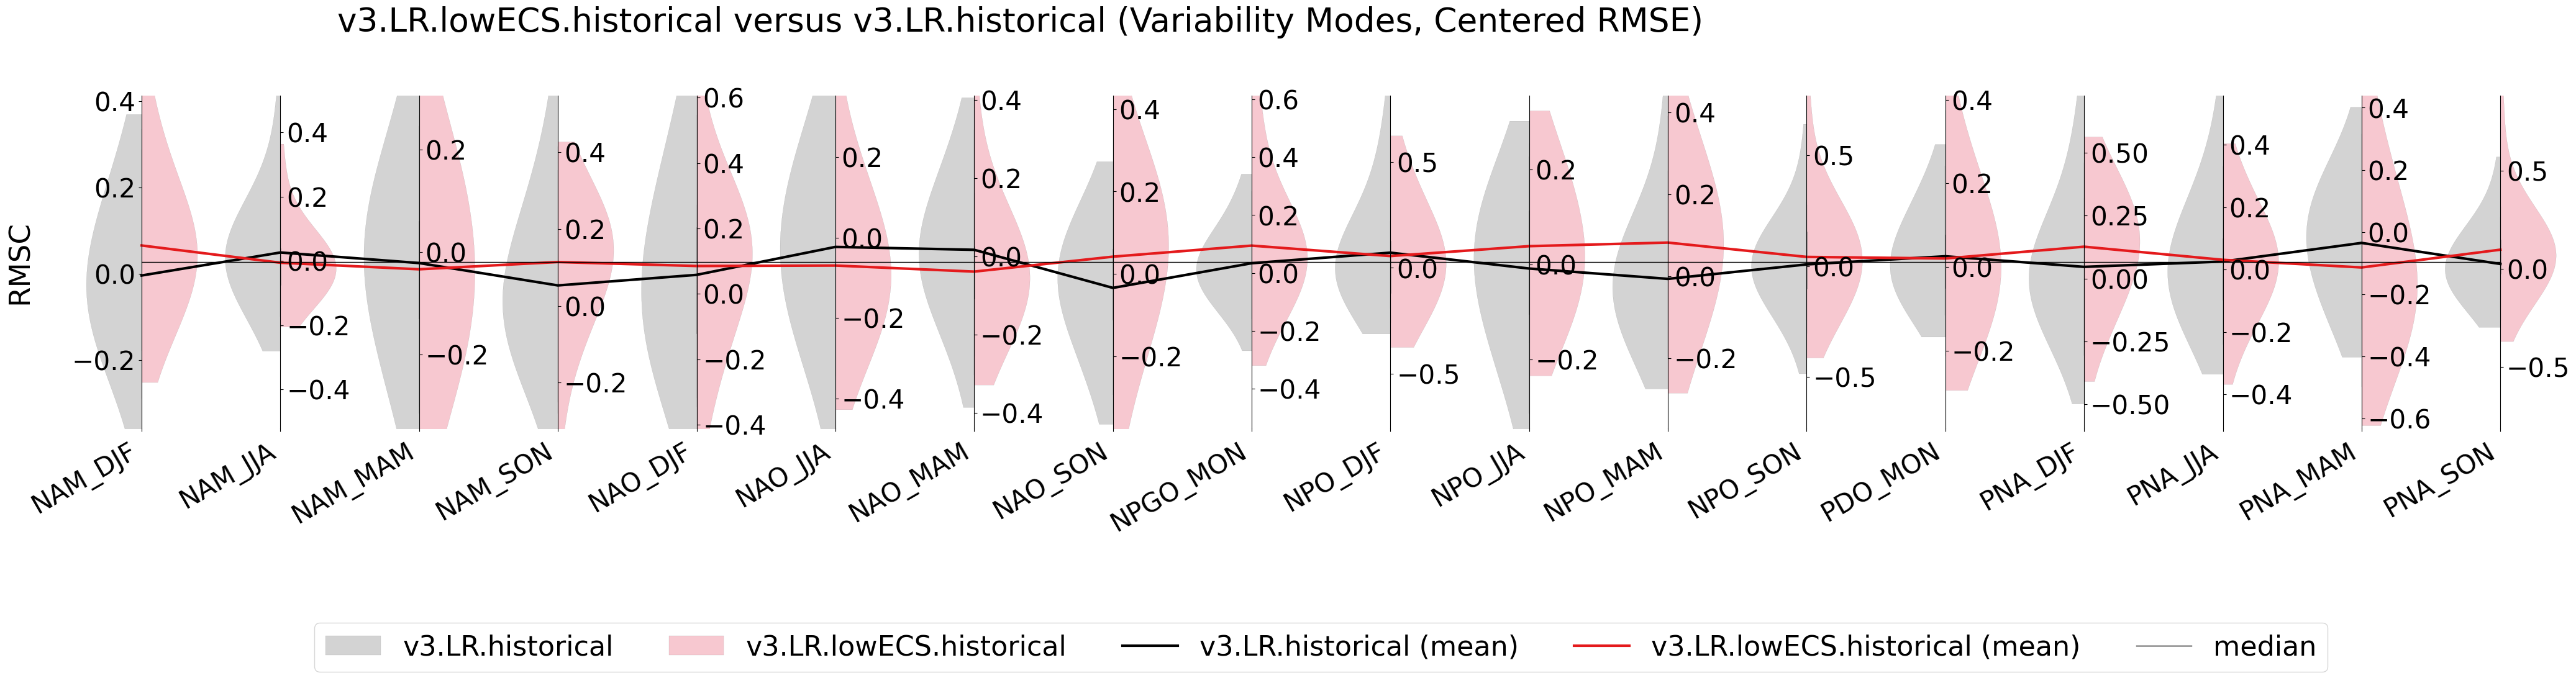

2026-08-28 17:16:53,844 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:928) >> Processing Portrait  Plots for variability_modes stdv_pc_ratio_to_obs....
2026-08-28 17:16:53,850 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1154) >> [Portrait]: No e3sm models to plot (e3sm_list empty).
2026-08-28 17:16:53,851 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1197) >> [Portrait] Highlighted model order: ['v3.LR.historical (mean)', 'v3.LR.lowECS.historical (mean)']


len(mode_season_list) = 18
data_nor shape = (18, 52)
data_nor.T shape = (52, 18)
existing data_dict shape = (52, 18)
existing columns (n) = 18


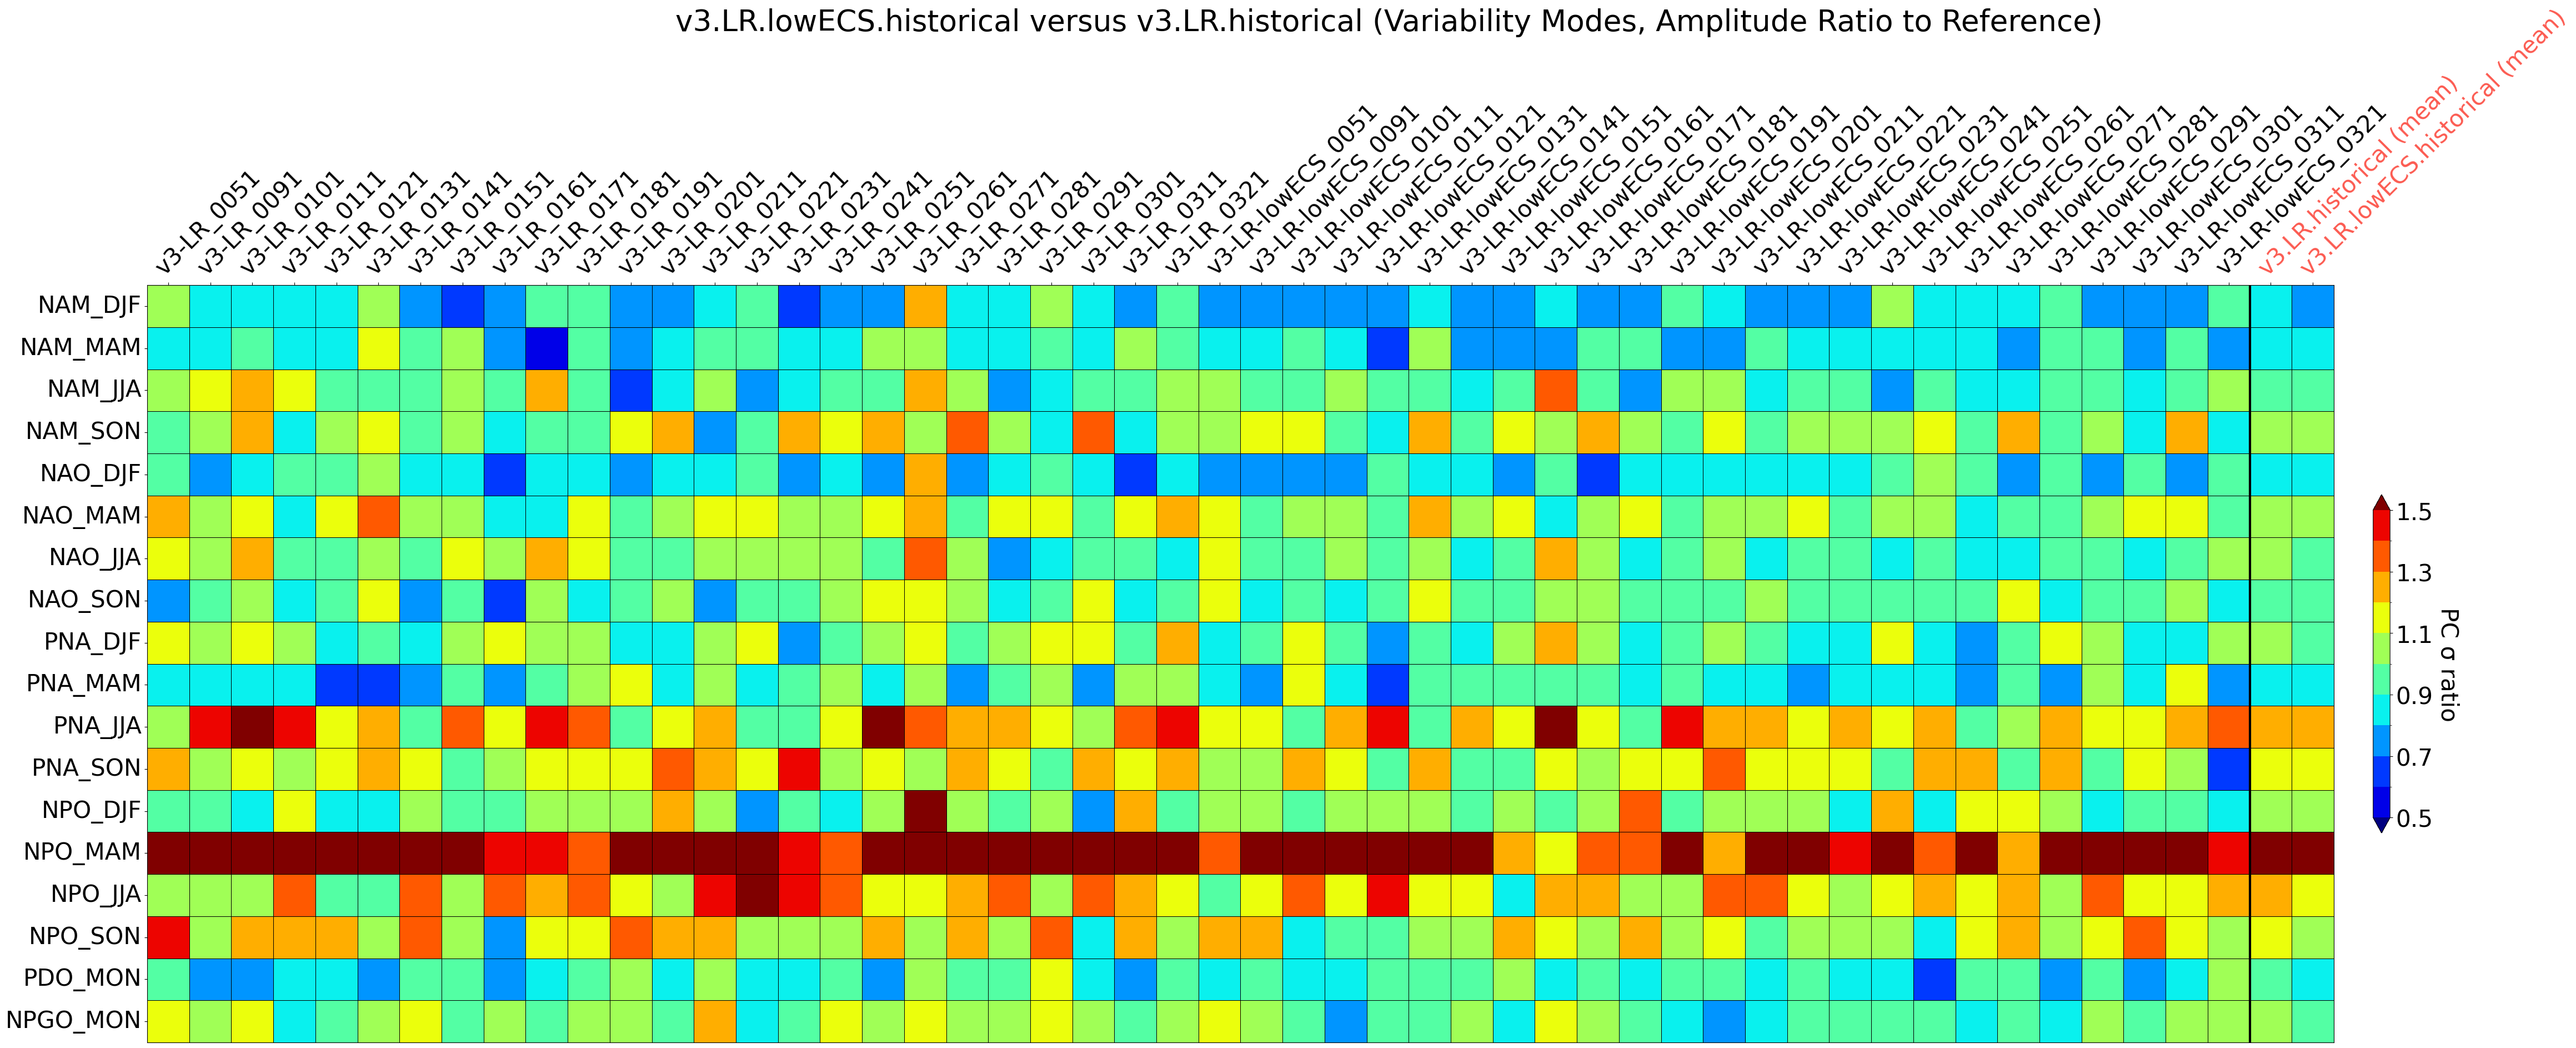

2026-08-28 17:16:55,682 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:979) >> Processing Parallel Coordinate Plots for variability_modes stdv_pc_ratio_to_obs....


Models in the second group: ['v3-LR-lowECS_0051', 'v3-LR-lowECS_0091', 'v3-LR-lowECS_0101', 'v3-LR-lowECS_0111', 'v3-LR-lowECS_0121', 'v3-LR-lowECS_0131', 'v3-LR-lowECS_0141', 'v3-LR-lowECS_0151', 'v3-LR-lowECS_0161', 'v3-LR-lowECS_0171', 'v3-LR-lowECS_0181', 'v3-LR-lowECS_0191', 'v3-LR-lowECS_0201', 'v3-LR-lowECS_0211', 'v3-LR-lowECS_0221', 'v3-LR-lowECS_0231', 'v3-LR-lowECS_0241', 'v3-LR-lowECS_0251', 'v3-LR-lowECS_0261', 'v3-LR-lowECS_0271', 'v3-LR-lowECS_0281', 'v3-LR-lowECS_0291', 'v3-LR-lowECS_0301', 'v3-LR-lowECS_0311', 'v3-LR-lowECS_0321', 'v3.LR.lowECS.historical (mean)']


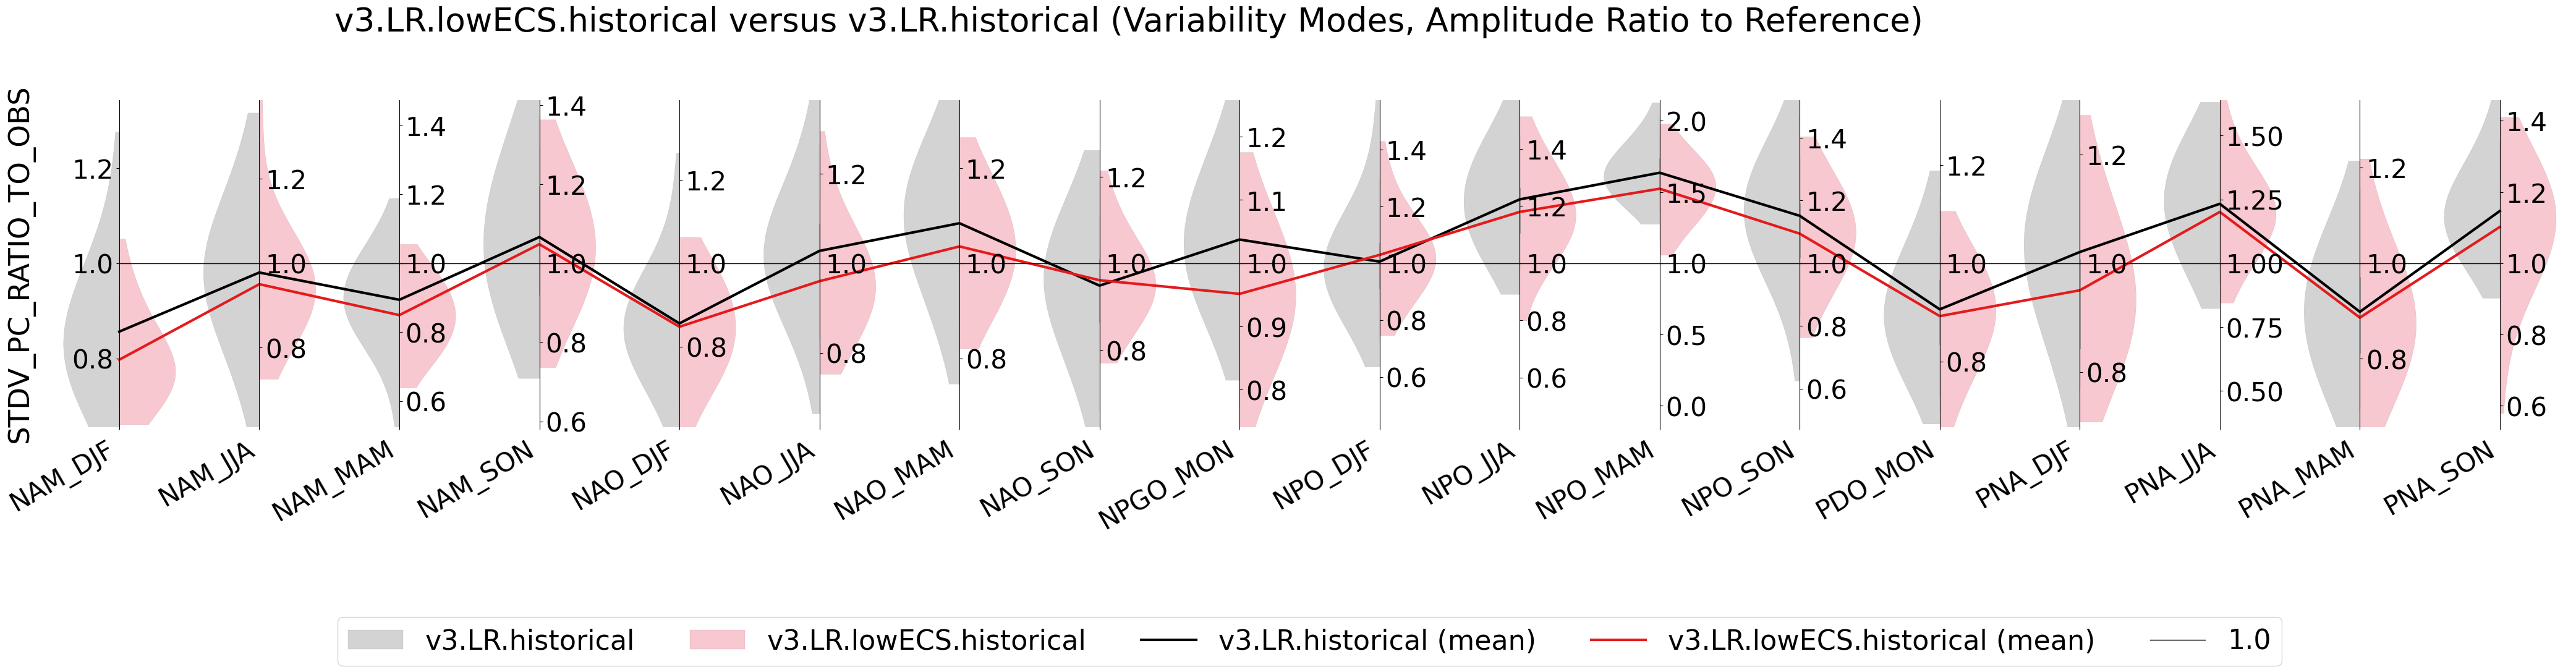

2026-08-28 17:16:58,859 [INFO]: synthetic_metrics_workflow.py(run_synthetic_plots:645) >> Generating synthetic metrics plots for case_id=v20260822
2026-08-28 17:16:58,860 [INFO]: synthetic_metrics_workflow.py(run_synthetic_plots:650) >> Generating figure_set=variability metrics=[] for case_id=v20260822
2026-08-28 17:16:58,862 [INFO]: synthetic_metrics_plotter.py(generate:366) >> Generating synthetic metrics plots ...
2026-08-28 17:16:58,862 [INFO]: synthetic_metrics_plotter.py(generate:392) >> Processing metric: variability_modes
2026-08-28 17:16:58,863 [INFO]: synthetic_metrics_plotter.py(_handle_variability_modes:493) >> Handling modes variability …
2026-08-28 17:16:58,863 [INFO]: movs_metrics_reader.py(_get_ref_files:159) >> From /pscratch/sd/z/zhan391/e3smv4_project/v4_evaluation/pcmdi_package/jupyter, checking for reference files matching /global/cfs/cdirs/e3sm/www/zhan391/e3sm_v3xle/metrics_data/variability_modes/e3sm/xle_historical/v20260822/*/*/var_mode_*.json
2026-08-28 17:16:

[INFO] Using PROJ data: /global/u2/z/zhan391/.conda/envs/e3sm_analysis/share/proj
Test group: v3.LR.highECS.historical
Reference group: v3.LR.historical
Models (0): []
Results: /global/cfs/cdirs/e3sm/www/zhan391/e3sm_v3xle/analysis_output/highECS_vs_historical/model_vs_obs
variability: []


2026-08-28 17:16:59,291 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:928) >> Processing Portrait  Plots for variability_modes rms....
2026-08-28 17:16:59,299 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1154) >> [Portrait]: No e3sm models to plot (e3sm_list empty).
2026-08-28 17:16:59,299 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1197) >> [Portrait] Highlighted model order: ['v3.LR.historical (mean)', 'v3.LR.highECS.historical (mean)']


len(mode_season_list) = 18
data_nor shape = (18, 52)
data_nor.T shape = (52, 18)
existing data_dict shape = (52, 18)
existing columns (n) = 18


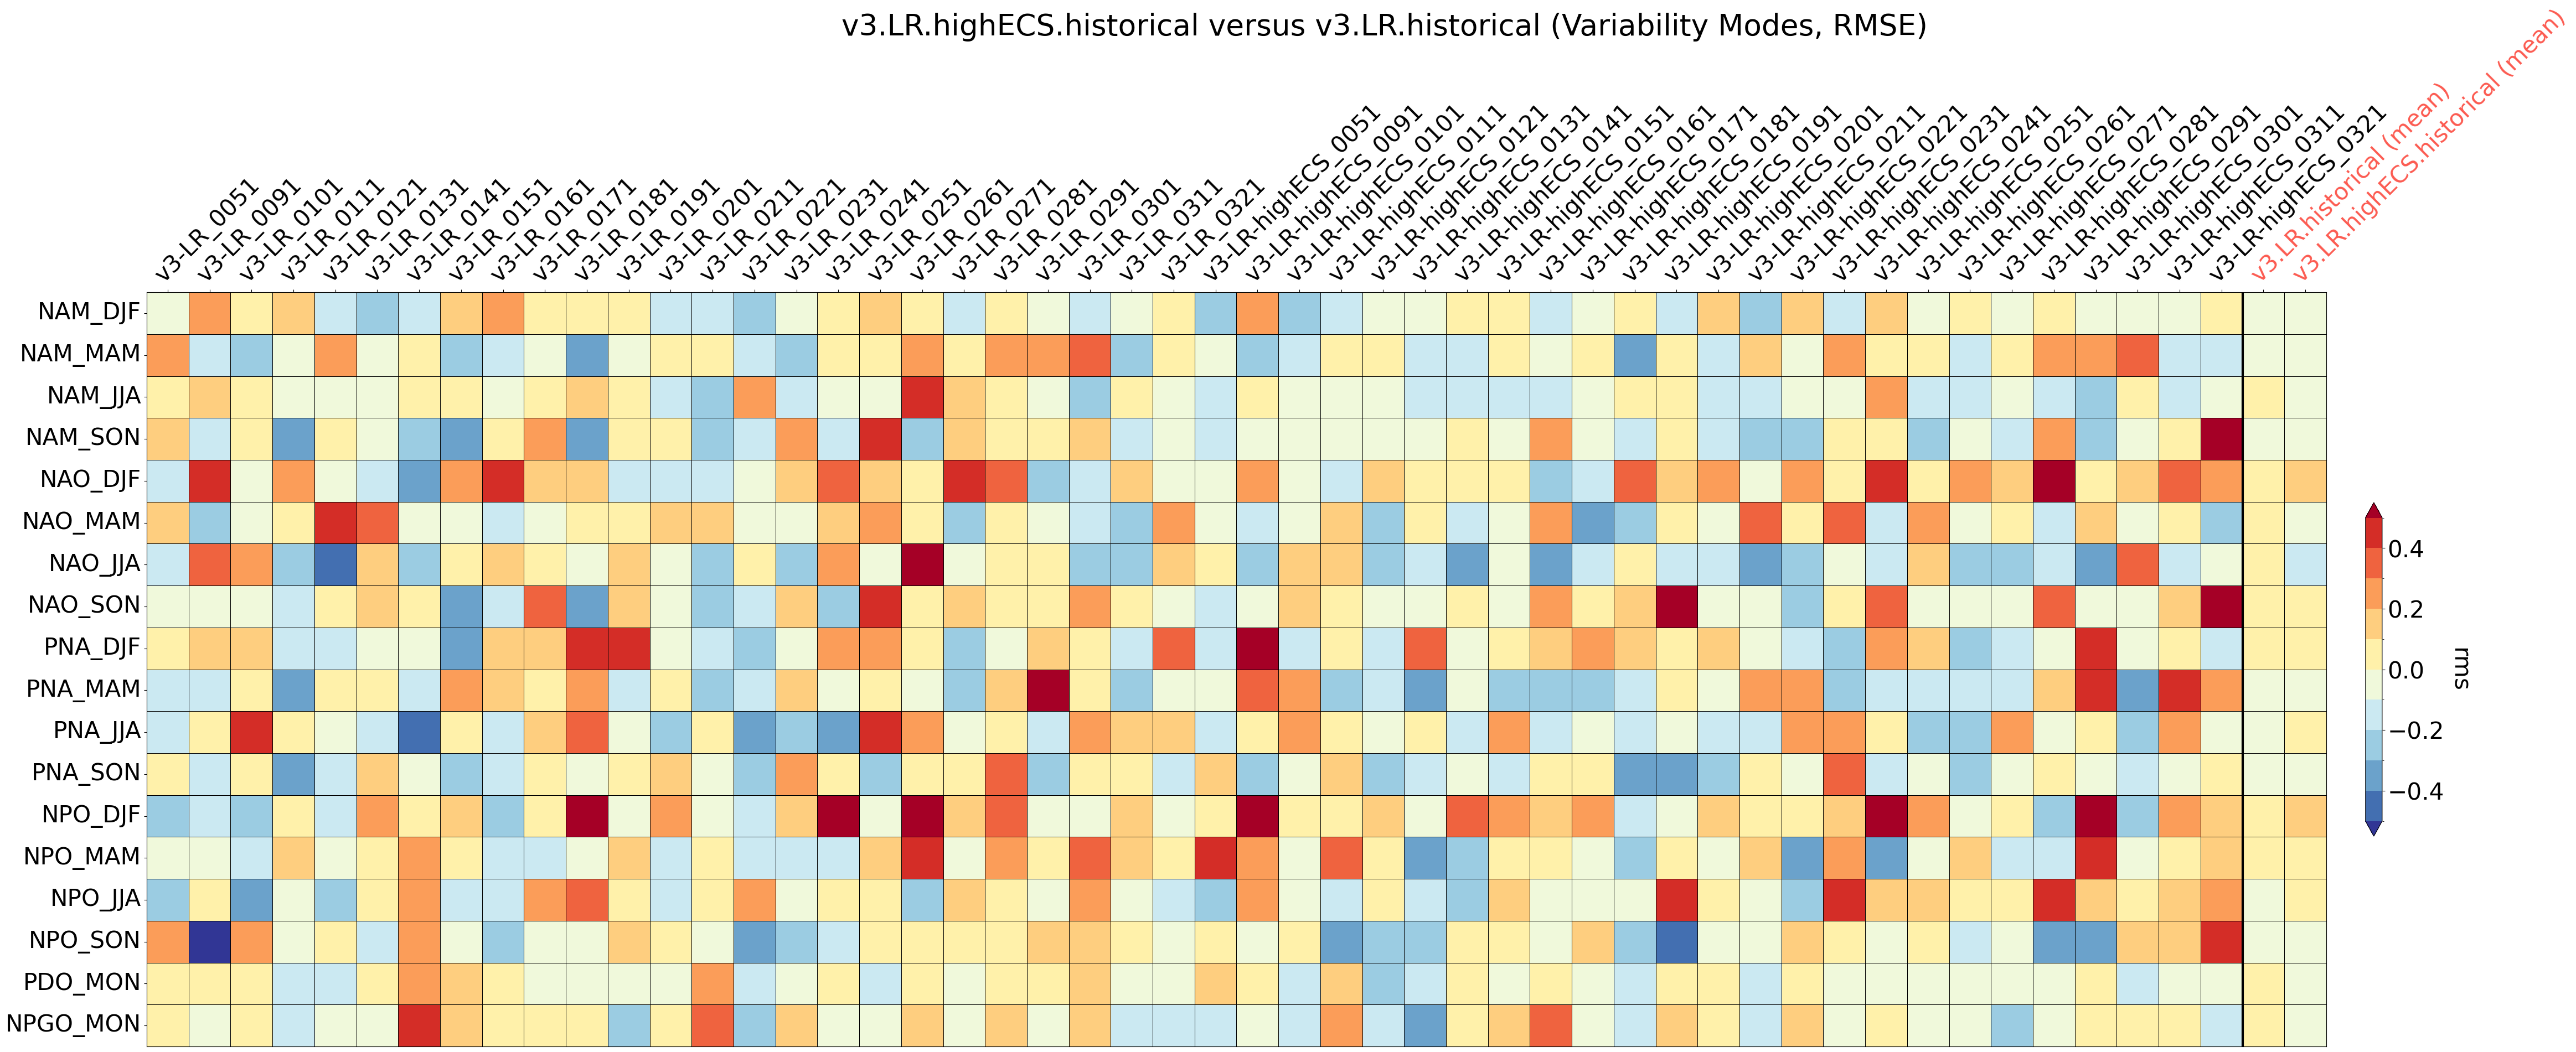

2026-08-28 17:17:01,485 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:979) >> Processing Parallel Coordinate Plots for variability_modes rms....


Models in the second group: ['v3-LR-highECS_0051', 'v3-LR-highECS_0091', 'v3-LR-highECS_0101', 'v3-LR-highECS_0111', 'v3-LR-highECS_0121', 'v3-LR-highECS_0131', 'v3-LR-highECS_0141', 'v3-LR-highECS_0151', 'v3-LR-highECS_0161', 'v3-LR-highECS_0171', 'v3-LR-highECS_0181', 'v3-LR-highECS_0191', 'v3-LR-highECS_0201', 'v3-LR-highECS_0211', 'v3-LR-highECS_0221', 'v3-LR-highECS_0231', 'v3-LR-highECS_0241', 'v3-LR-highECS_0251', 'v3-LR-highECS_0261', 'v3-LR-highECS_0271', 'v3-LR-highECS_0281', 'v3-LR-highECS_0291', 'v3-LR-highECS_0301', 'v3-LR-highECS_0311', 'v3-LR-highECS_0321', 'v3.LR.highECS.historical (mean)']


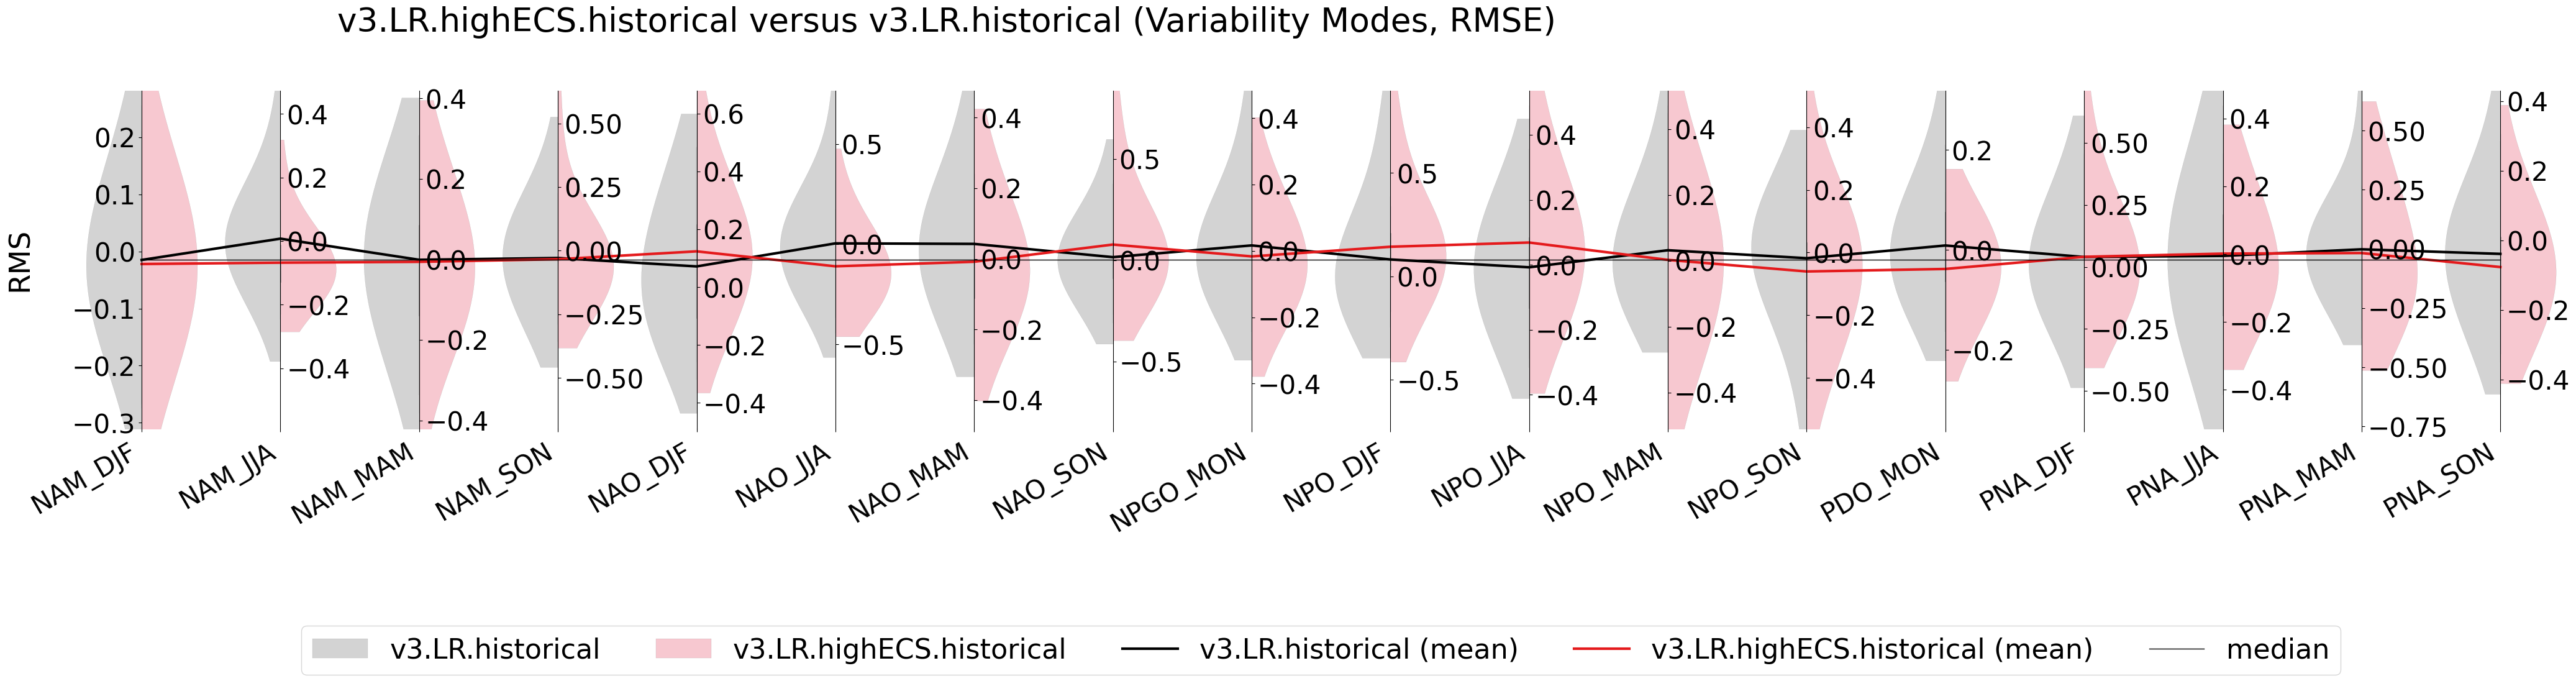

2026-08-28 17:17:03,912 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:928) >> Processing Portrait  Plots for variability_modes rmsc....
2026-08-28 17:17:03,920 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1154) >> [Portrait]: No e3sm models to plot (e3sm_list empty).
2026-08-28 17:17:03,921 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1197) >> [Portrait] Highlighted model order: ['v3.LR.historical (mean)', 'v3.LR.highECS.historical (mean)']


len(mode_season_list) = 18
data_nor shape = (18, 52)
data_nor.T shape = (52, 18)
existing data_dict shape = (52, 18)
existing columns (n) = 18


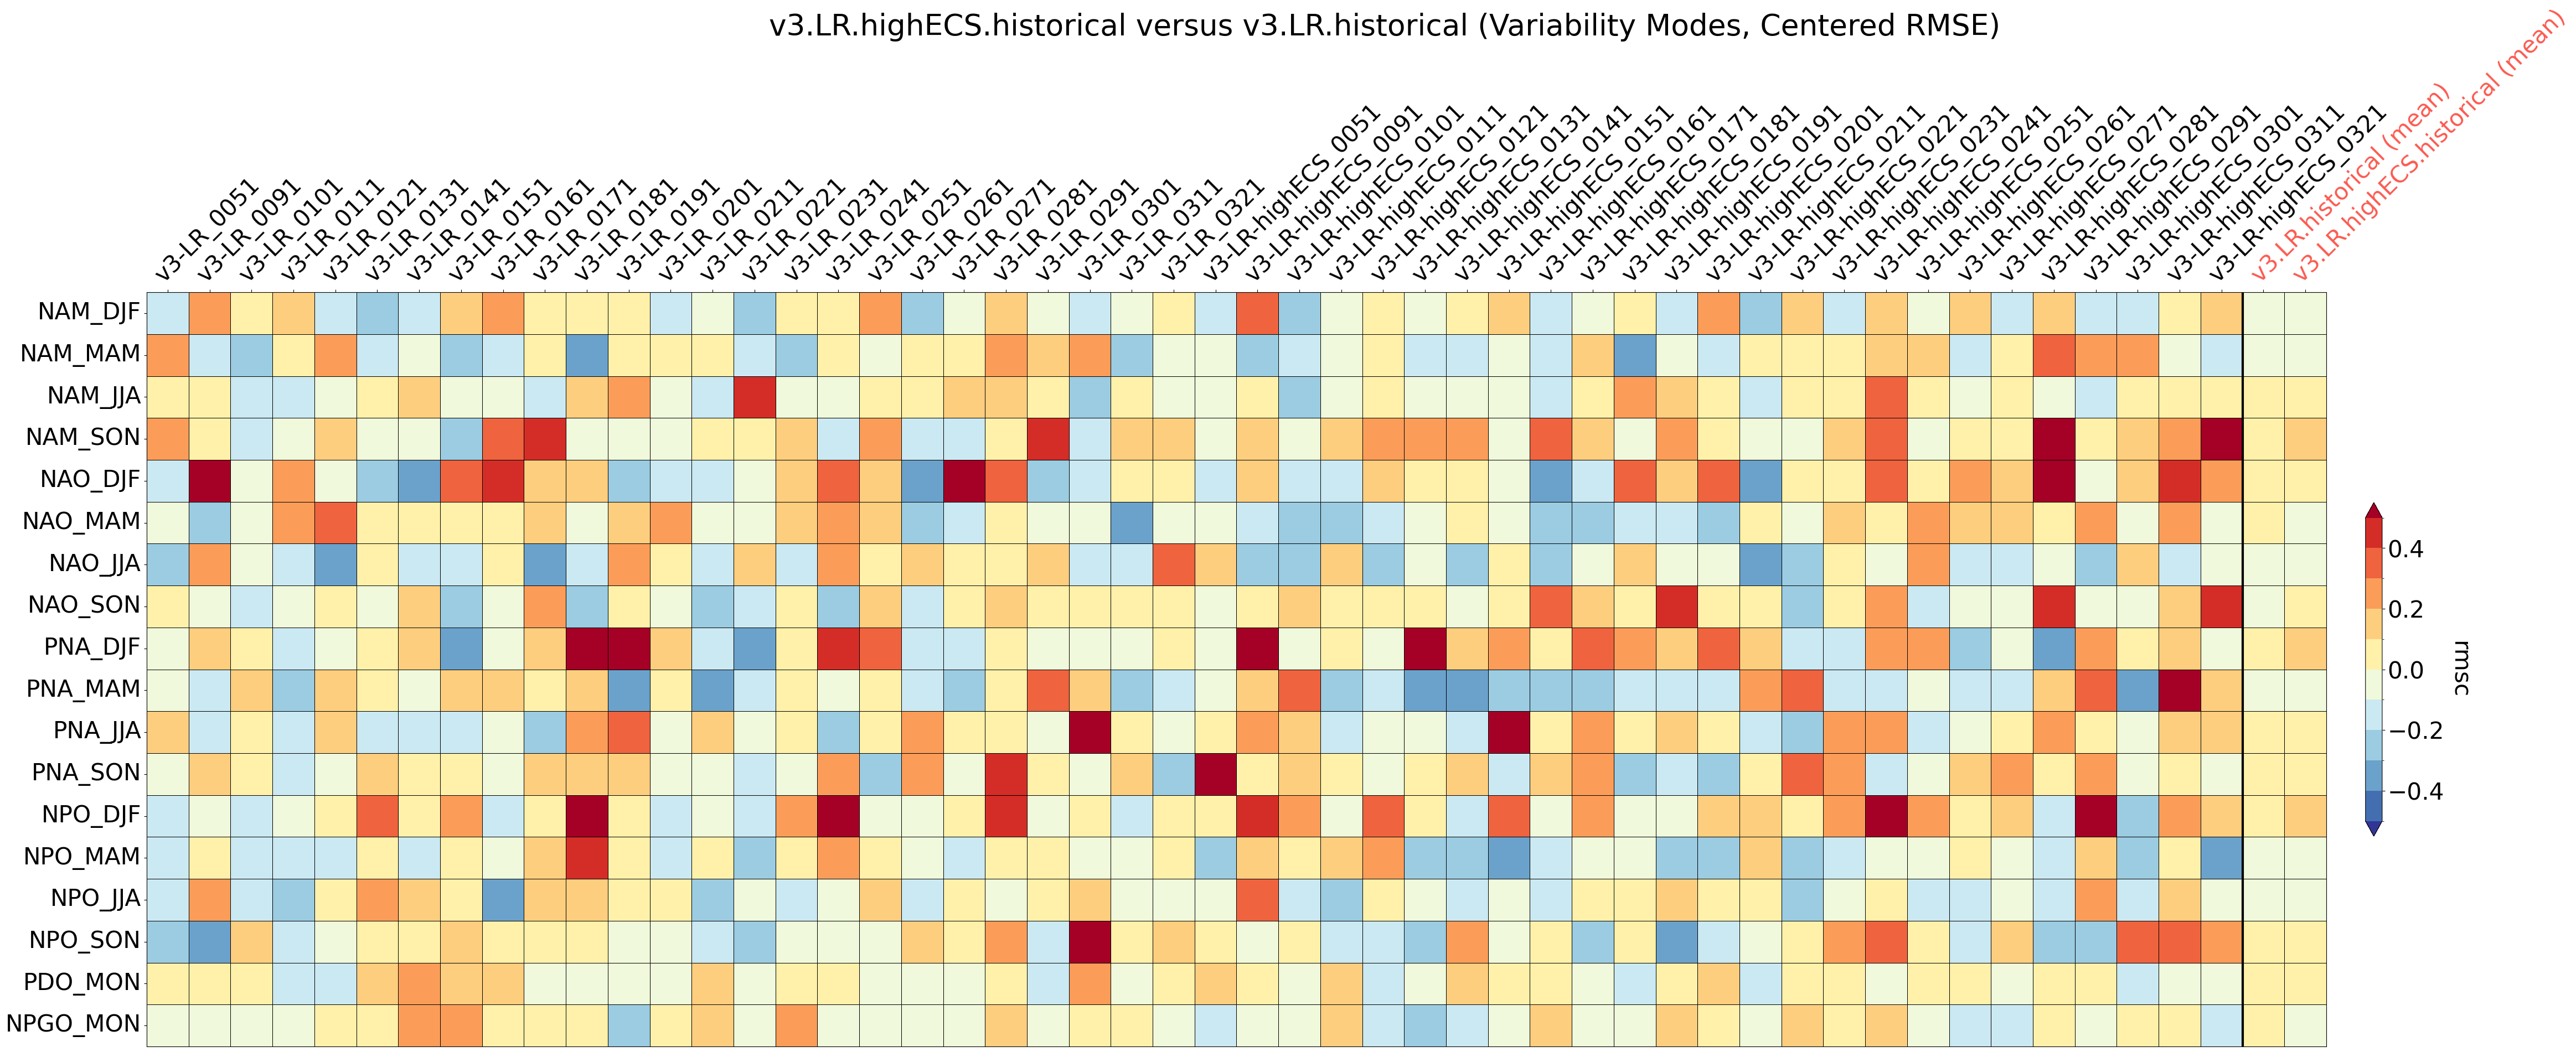

2026-08-28 17:17:05,800 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:979) >> Processing Parallel Coordinate Plots for variability_modes rmsc....


Models in the second group: ['v3-LR-highECS_0051', 'v3-LR-highECS_0091', 'v3-LR-highECS_0101', 'v3-LR-highECS_0111', 'v3-LR-highECS_0121', 'v3-LR-highECS_0131', 'v3-LR-highECS_0141', 'v3-LR-highECS_0151', 'v3-LR-highECS_0161', 'v3-LR-highECS_0171', 'v3-LR-highECS_0181', 'v3-LR-highECS_0191', 'v3-LR-highECS_0201', 'v3-LR-highECS_0211', 'v3-LR-highECS_0221', 'v3-LR-highECS_0231', 'v3-LR-highECS_0241', 'v3-LR-highECS_0251', 'v3-LR-highECS_0261', 'v3-LR-highECS_0271', 'v3-LR-highECS_0281', 'v3-LR-highECS_0291', 'v3-LR-highECS_0301', 'v3-LR-highECS_0311', 'v3-LR-highECS_0321', 'v3.LR.highECS.historical (mean)']


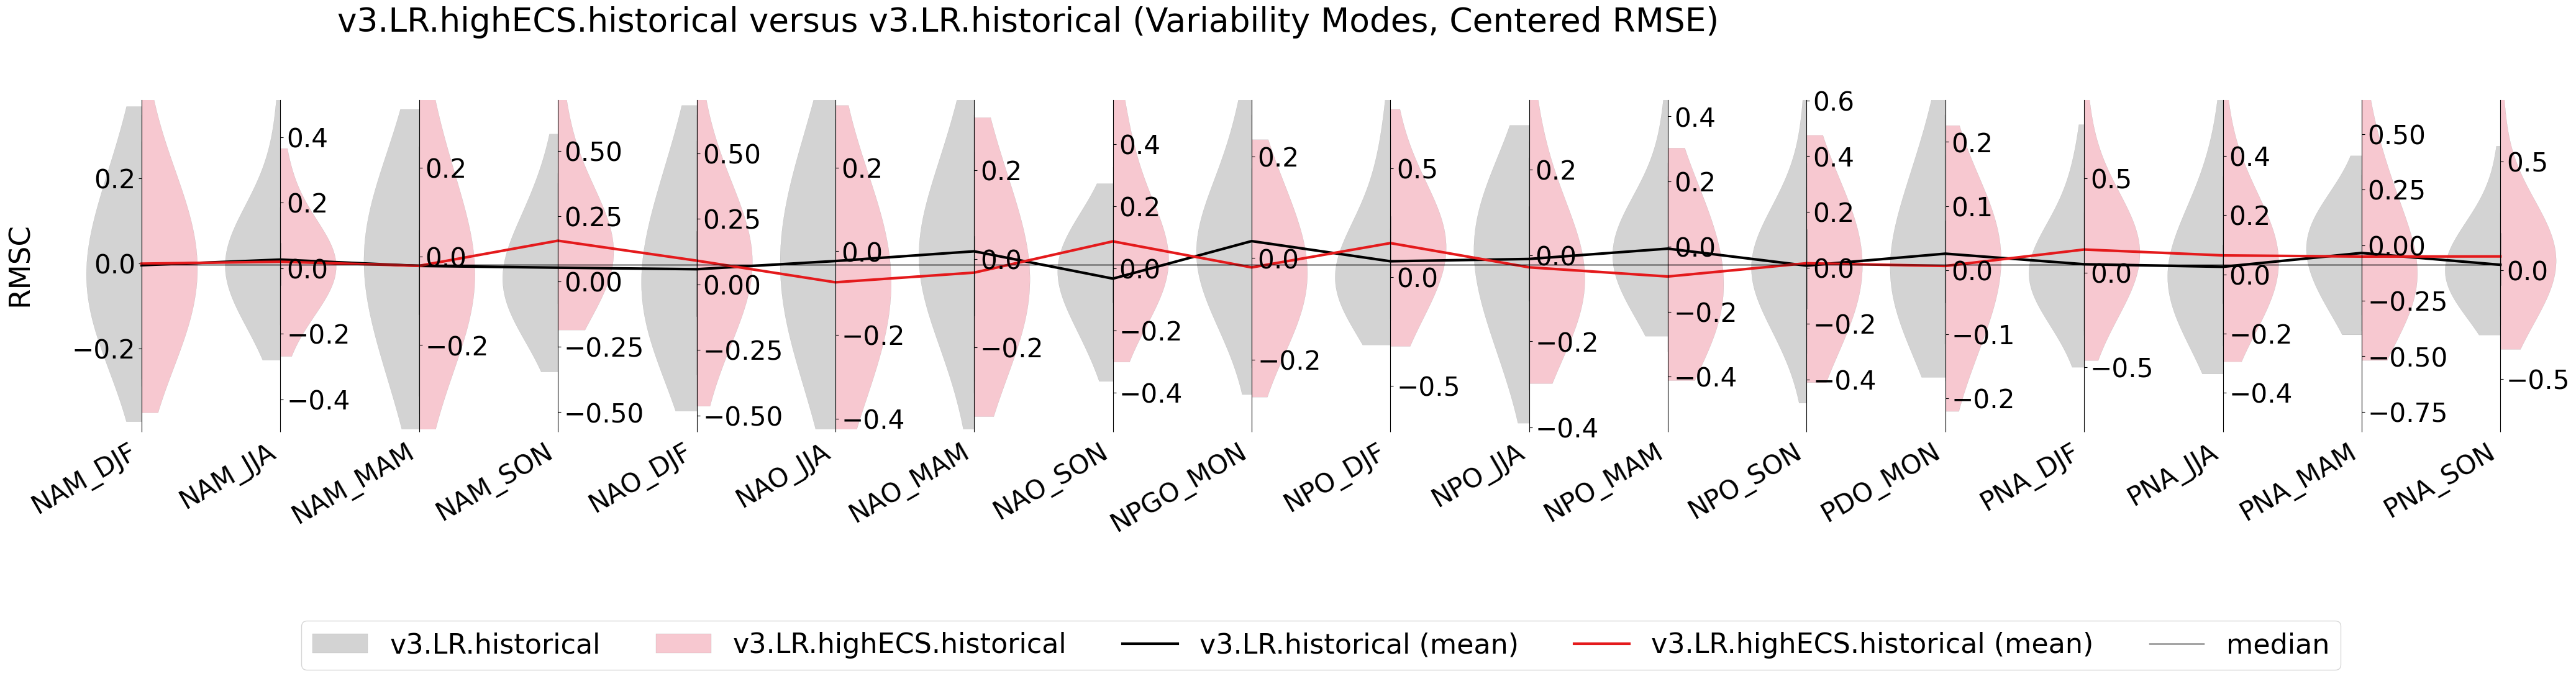

2026-08-28 17:17:08,504 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:928) >> Processing Portrait  Plots for variability_modes stdv_pc_ratio_to_obs....
2026-08-28 17:17:08,510 [WARNING]: synthetic_metrics_plotter.py(portrait_metric_plot:1154) >> [Portrait]: No e3sm models to plot (e3sm_list empty).
2026-08-28 17:17:08,510 [INFO]: synthetic_metrics_plotter.py(portrait_metric_plot:1197) >> [Portrait] Highlighted model order: ['v3.LR.historical (mean)', 'v3.LR.highECS.historical (mean)']


len(mode_season_list) = 18
data_nor shape = (18, 52)
data_nor.T shape = (52, 18)
existing data_dict shape = (52, 18)
existing columns (n) = 18


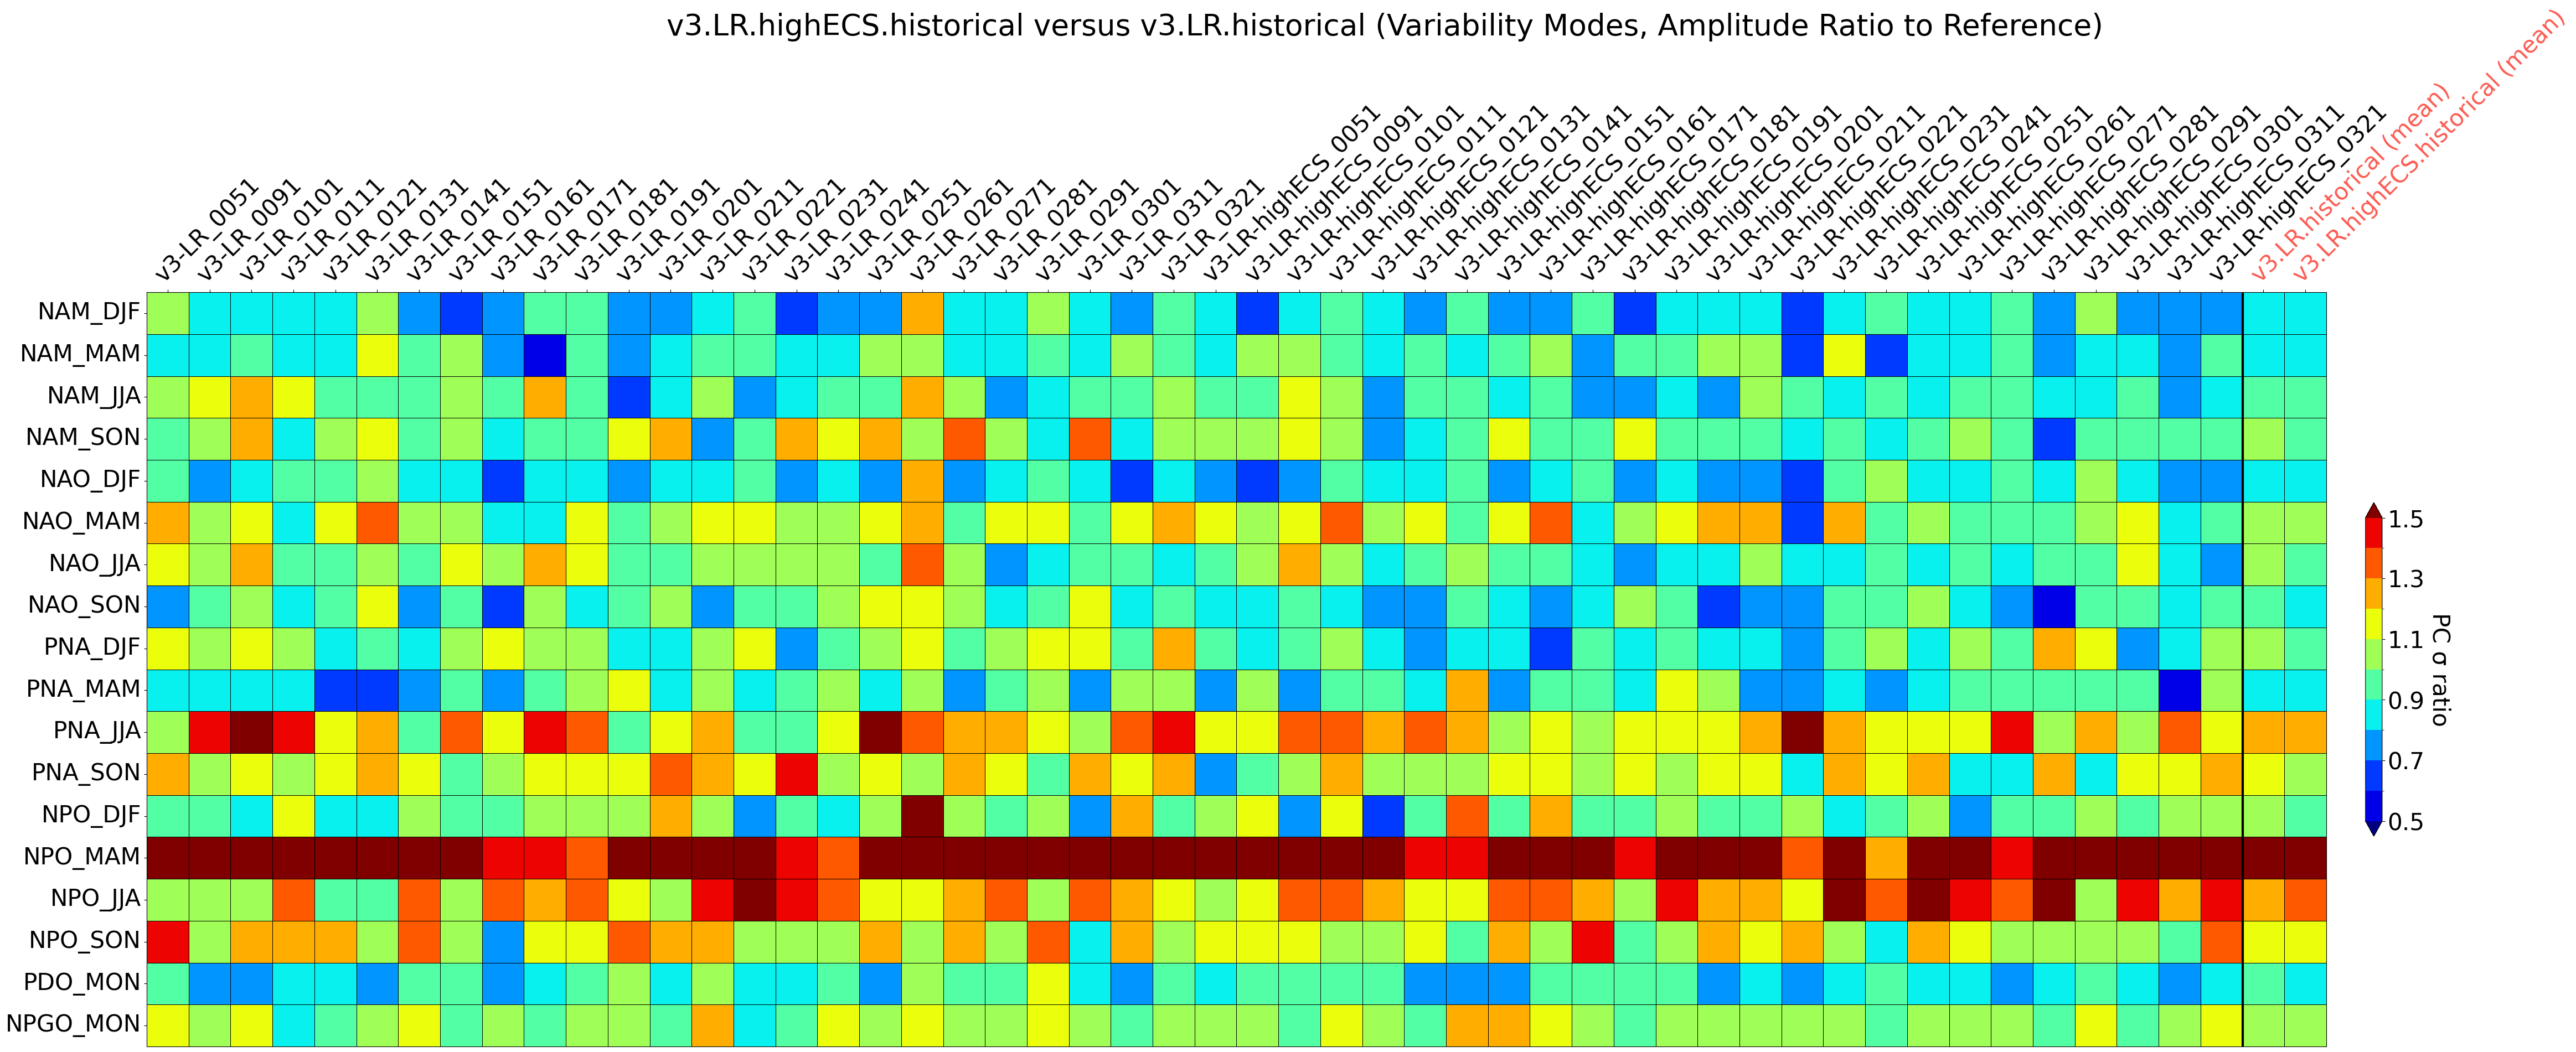

2026-08-28 17:17:10,415 [INFO]: synthetic_metrics_plotter.py(variability_modes_plot_driver:979) >> Processing Parallel Coordinate Plots for variability_modes stdv_pc_ratio_to_obs....


Models in the second group: ['v3-LR-highECS_0051', 'v3-LR-highECS_0091', 'v3-LR-highECS_0101', 'v3-LR-highECS_0111', 'v3-LR-highECS_0121', 'v3-LR-highECS_0131', 'v3-LR-highECS_0141', 'v3-LR-highECS_0151', 'v3-LR-highECS_0161', 'v3-LR-highECS_0171', 'v3-LR-highECS_0181', 'v3-LR-highECS_0191', 'v3-LR-highECS_0201', 'v3-LR-highECS_0211', 'v3-LR-highECS_0221', 'v3-LR-highECS_0231', 'v3-LR-highECS_0241', 'v3-LR-highECS_0251', 'v3-LR-highECS_0261', 'v3-LR-highECS_0271', 'v3-LR-highECS_0281', 'v3-LR-highECS_0291', 'v3-LR-highECS_0301', 'v3-LR-highECS_0311', 'v3-LR-highECS_0321', 'v3.LR.highECS.historical (mean)']


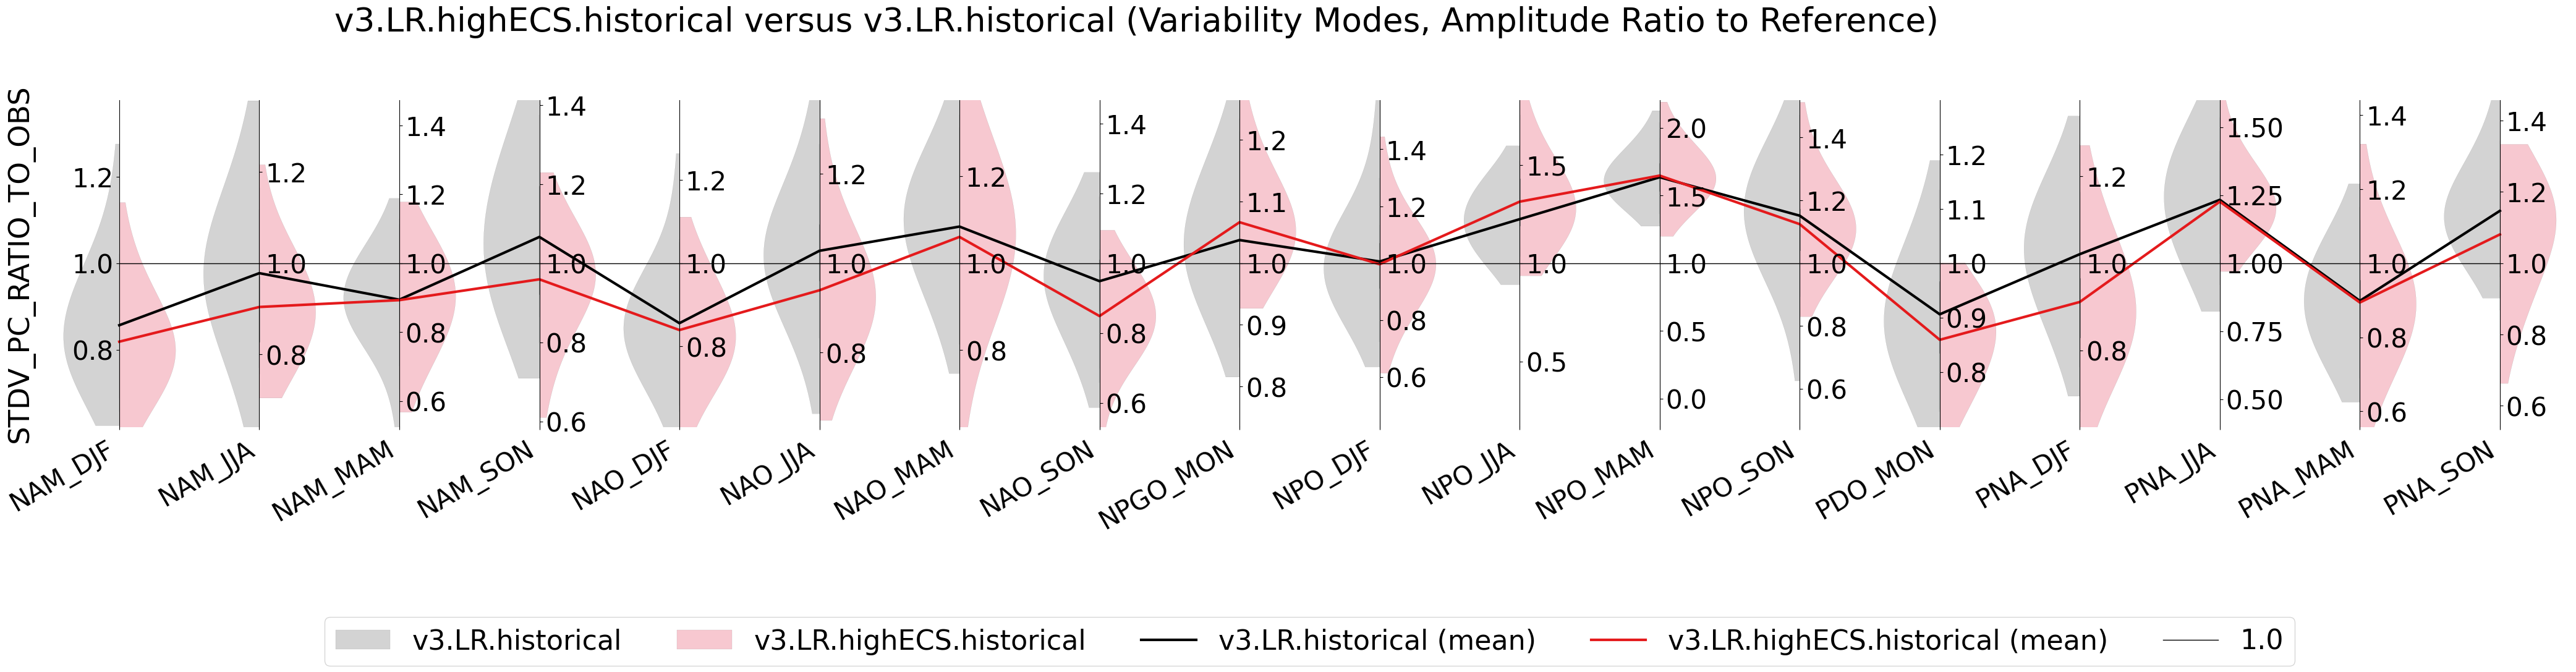

In [9]:
if MOV_MVM_XLE_RUN_MERGE:
    for group in MOV_MVM_XLE_GROUPS.values():
        merge_metrics_group(
            group, metrics_root=MOV_MVM_XLE_METRICS_DATA_ROOT,
            run_type="model_vs_obs", enable_clim=False, enable_movs=True,
            enable_enso=False, strict=True, verbose=True,
            dry_run=MOV_MVM_XLE_DRY_RUN_MERGE, clean=MOV_MVM_XLE_CLEAN_MERGED_OUTPUT,
        )

MOV_MVM_XLE_REF_DATASET = dataset_for_merged_group(
    mip=MOV_MVM_XLE_MIP, group=MOV_MVM_XLE_REF_MERGED_GROUP,
    case_id=MOV_MVM_XLE_CASE_ID, root=MOV_MVM_XLE_METRICS_DATA_ROOT,
)

mov_mvm_xle_parameters = {}
for comparison in MOV_MVM_XLE_COMPARISONS:
    test_group = MOV_MVM_XLE_GROUPS[comparison["group"]]
    test_dataset = dataset_for_merged_group(
        mip=MOV_MVM_XLE_MIP, group=test_group.name,
        case_id=MOV_MVM_XLE_CASE_ID, root=MOV_MVM_XLE_METRICS_DATA_ROOT,
    )
    parameters = make_comparison_parameters(
        case_id=MOV_MVM_XLE_CASE_ID,
        ref_group=MOV_MVM_XLE_REF_GROUP_LABEL, test_group=comparison["label"],
        ref_dataset=MOV_MVM_XLE_REF_DATASET, test_dataset=test_dataset,
        metrics_root=MOV_MVM_XLE_METRICS_DATA_ROOT,
        out_dir=MOV_MVM_XLE_FIG_ROOT / comparison["key"],
        test_combined=True, test_model_only=False,
        show_mean_columns=MOV_MVM_XLE_SHOW_MEAN_COLUMNS,
        movs_group=MOV_MVM_XLE_MOVS_GROUP,
        movs_expand_realizations=True,
        atm_modes=MOV_MVM_XLE_ATM_MODES, atm_obs=MOV_MVM_XLE_ATM_OBS,
        cpl_modes=MOV_MVM_XLE_CPL_MODES, cpl_obs=MOV_MVM_XLE_CPL_OBS,
        error_norm=MOV_MVM_XLE_ERROR_NORM, figure_format=MOV_MVM_XLE_FIGURE_FORMAT,
        mov_font_size=MOV_MVM_XLE_FONT_SIZE, mov_figure_size=MOV_MVM_XLE_FIGURE_SIZE,
        mov_portrait_figure_size=MOV_MVM_XLE_PORTRAIT_FIGURE_SIZE,
        mov_parcoord_figure_size=MOV_MVM_XLE_PARCOORD_FIGURE_SIZE,
        mov_parcoord_legend_y_offset=MOV_MVM_XLE_PARCOORD_LEGEND_Y_OFFSET,
        clim_viewer=MOV_MVM_XLE_CLIM_VIEWER, mova_viewer=MOV_MVM_XLE_MOVA_VIEWER,
        movc_viewer=MOV_MVM_XLE_MOVC_VIEWER, enso_viewer=MOV_MVM_XLE_ENSO_VIEWER,
        mean_group1_name=f"{MOV_MVM_XLE_REF_GROUP_LABEL} (mean)",
        mean_group2_name=f"{comparison['label']} (mean)",
    )
    mov_mvm_xle_parameters[comparison["key"]] = parameters

    if MOV_MVM_XLE_RUN_PLOTS:
        run_synthetic_plots(
            parameters, title_label=f"{comparison['label']} versus {MOV_MVM_XLE_REF_GROUP_LABEL}",
            metric_file=MOV_MVM_XLE_METRIC_CONFIG_FILE,
            metric_selection={"variability_modes": MOV_MVM_XLE_METRICS},
            show_figures=MOV_MVM_XLE_SHOW_FIGURES, debug=MOV_MVM_XLE_DEBUG,
        )

if not MOV_MVM_XLE_RUN_PLOTS:
    print("Set MOV_MVM_XLE_RUN_PLOTS = True to generate figures.")
